In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:

npzfile = np.load('run_nk7_ndiag11.npz')
print(npzfile.files)
ID_list=npzfile['ID_list']
nen_list=npzfile['nen_list']
nsub_list=npzfile['nsub_list']

['ID_list', 'nen_list', 'nsub_list', 'tr', 'energies', 'Gr_diag', 'Gn_diag']


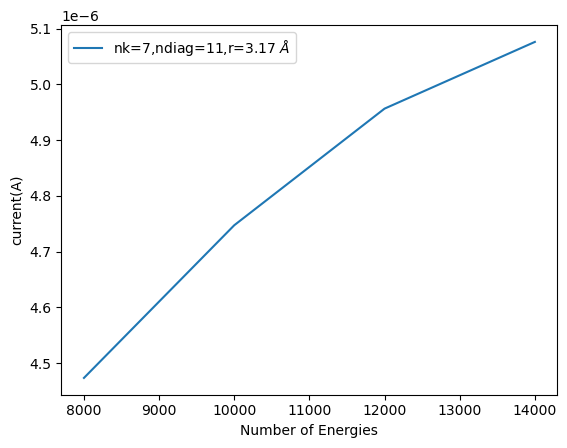

In [3]:
Lx=3.1680940
plt.plot(nen_list,ID_list[0,0,:],label='nk=7,'+'ndiag=11'+',r='+'{:.2f}'.format(Lx*1)+r" $\AA$")
plt.xlabel('Number of Energies')
plt.ylabel('current(A)')
plt.legend()

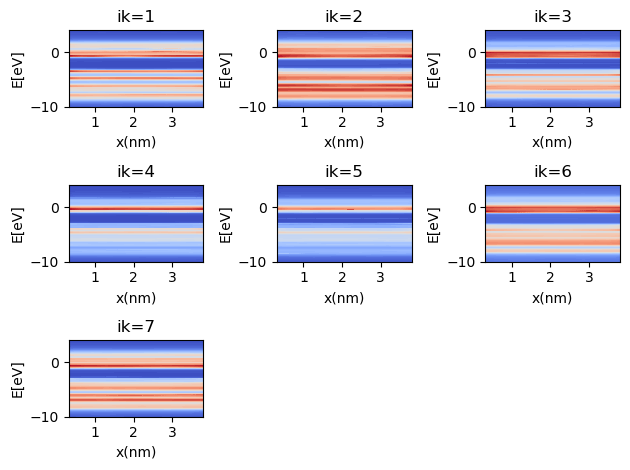

In [4]:
nx=12
Lx=3.1680940
emin=-10.0
emax=4.0
for i in range(7):
    plt.subplot(3,3,i+1)
    plt.title('ik='+str(i+1))
    ldos=np.loadtxt('last_ldos000'+str(i+1)+'.dat')
    nen=ldos.shape[0]//nx
    en=np.linspace(emin,emax,nen)
    x=np.linspace(1,nx,nx)*Lx
    ldos=np.reshape(ldos[:,3],(nen,nx))
    plt.contourf(x/10,en,ldos,100, cmap='coolwarm')
    plt.xlabel('x(nm)')
    plt.ylabel('E[eV]')
    plt.tight_layout()
plt.show()    

Text(0, 0.5, 'E[eV]')

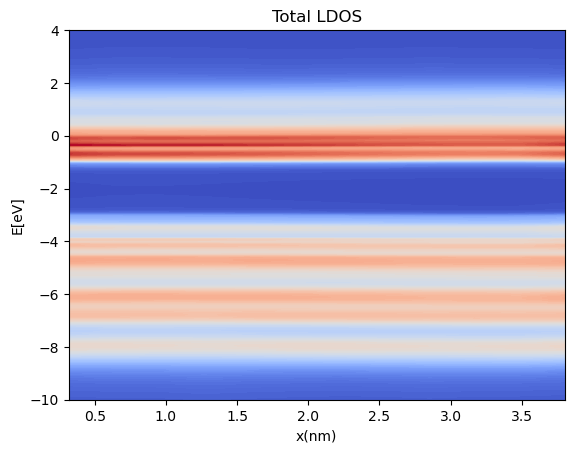

In [5]:
nx=12
Lx=3.1680940
emin=-10.0
emax=4.0
plt.title('Total LDOS')
ldos=np.loadtxt('gw_ldos0048.dat')
nen=ldos.shape[0]//nx
en=np.linspace(emin,emax,nen)
x=np.linspace(1,nx,nx)*Lx
ldos=np.reshape(ldos[:,3],(nen,nx))
plt.contourf(x/10,en,ldos,100, cmap='coolwarm')
plt.xlabel('x(nm)')
plt.ylabel('E[eV]')

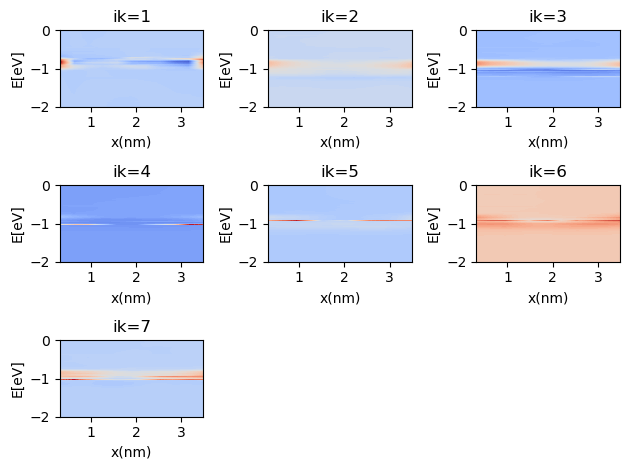

In [6]:
nx=11
Lx=3.1680940
emin=-10.0
emax=4.0
for i in range(7):
    plt.subplot(3,3,i+1)
    plt.title('ik='+str(i+1))
    ldos=np.loadtxt('last_Jdens000'+str(i+1)+'.dat')
    nen=ldos.shape[0]//nx
    en=np.linspace(emin,emax,nen)
    x=np.linspace(1,nx,nx)*Lx
    ldos=np.reshape(ldos[:,2],(nen,nx))
    plt.contourf(x/10,en,ldos,100, cmap='coolwarm')
    plt.xlabel('x(nm)')
    plt.ylabel('E[eV]')
    plt.ylim(-2,0)
    # plt.colorbar()
    plt.tight_layout()


(-2.0, 0.0)

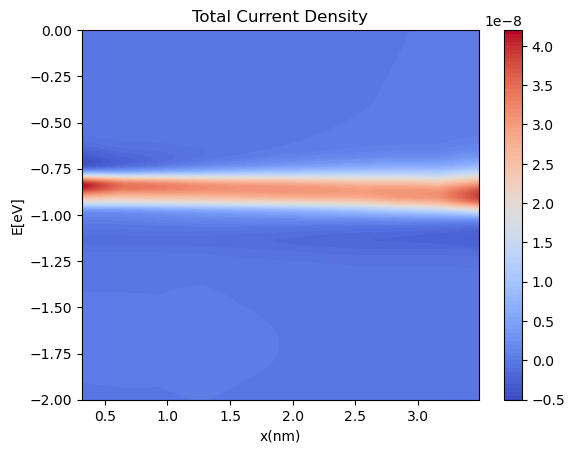

In [7]:
nx=11
Lx=3.1680940
emin=-10.0
emax=4.0
plt.title('Total Current Density')
ldos=np.loadtxt('gw_Jdens0048.dat')
nen=ldos.shape[0]//nx
en=np.linspace(emin,emax,nen)
x=np.linspace(1,nx,nx)*Lx
ldos=np.reshape(ldos[:,2],(nen,nx))
plt.contourf(x/10,en,ldos,100, cmap='coolwarm')
plt.xlabel('x(nm)')
plt.ylabel('E[eV]')
plt.colorbar()
plt.ylim(-2,0)

In [8]:
ids=np.loadtxt('gw_Id_iteration.dat')
error=np.loadtxt('gw_scba_error.dat')
it=ids[:,0]
nn=[0]
for j in range(1,len(it)):
    if(it[j]<it[j-1]):
        nn.append(j)
it2=error[:,0]
nn2=[0]
for j in range(1,len(it2)):
    if(it2[j]<it2[j-1]):
        nn2.append(j)        

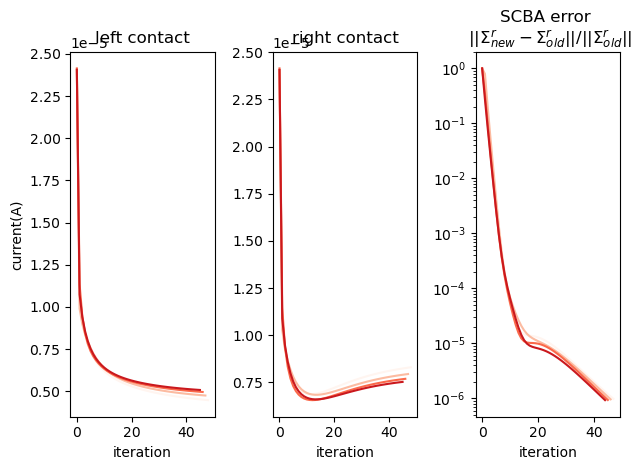

In [9]:
from matplotlib import cm
brewer_cmap = cm.get_cmap('Reds')
colors = brewer_cmap(np.linspace(0,1,len(nn)))

plt.subplot(1,3,1)
for i in range(len(nn)-1):    
    plt.plot(it[nn[i]:nn[i+1]], ids[nn[i]:nn[i+1],1],c=colors[i])    
plt.xlabel('iteration')
plt.ylabel('current(A)')
plt.title('left contact')
plt.subplot(1,3,2)
for i in range(len(nn)-1):    
    plt.plot(it[nn[i]:nn[i+1]], ids[nn[i]:nn[i+1],2],c=colors[i])    
plt.xlabel('iteration')
plt.ylabel('')
plt.title('right contact')
plt.subplot(1,3,3)
for i in range(len(nn2)-1):    
    plt.plot(it2[nn2[i]:nn2[i+1]], error[nn2[i]:nn2[i+1],1],c=colors[i])    
plt.xlabel('iteration')
plt.ylabel('')
plt.title('SCBA error \n $||\Sigma^r_{new}-\Sigma^r_{old}||/||\Sigma^r_{old}||$')
plt.yscale('log')
plt.tight_layout()